In [9]:
from algorithm import ImpedanceAnalyzer
from audio import AudioEngine, SignalGenerator
from stepper import StepperController
import serial.tools.list_ports
import time
import matplotlib.pyplot as plt

### Settings

#### basic parameters

In [2]:
TEMPERATURE = 25.0  # celsuis
SAMPLE_RATE = 48000  # hz
EXCITATION_DURATION = 1.0  # excitation signal duration (s)
AMPLITUDE_DB = -6  # excitation signal amplitude (dBFS)
F_START, F_END = (20, 20000)  # excitation signal frequency range (Hz)

MIC1_POS = 2
MIC2_POS = 2.55
MIC3_POS = 2.95

#### audio engine settings

In [3]:
#  1. generate signal
signal_gen = SignalGenerator(fs=SAMPLE_RATE, amplitude_db=AMPLITUDE_DB)
signal = signal_gen.generate_sweep(duration=EXCITATION_DURATION, f_start=F_START, f_end=F_END)
#  2. list device
audio_engine = AudioEngine(fs=SAMPLE_RATE)
audio_engine.list_devices()

ID  Name                                     API        In   Out 
----------------------------------------------------------------------
0   BlackHole 2ch                            Core Audio 2    2    *
1   MacBook Air Microphone                   Core Audio 1    0    
2   MacBook Air Speakers                     Core Audio 0    2    
3   Aggregate Device                         Core Audio 1    2    *
----------------------------------------------------------------------
Default Input: 1, Default Output: 2


In [4]:
# 3. choose device
input_id = 3   
output_id = 3  
audio_engine.select_device(input_id=input_id, output_id=output_id)

-> Selected input device [3]: Aggregate Device
-> Selected output device [3]: Aggregate Device


#### motor settings

In [5]:
# 1. list serial ports
ports = serial.tools.list_ports.comports()
if not ports:
    print("No serial ports found.")
print("Available serial ports:")
for port in ports:
    print(f" - {port.device}")


Available serial ports:
 - /dev/cu.debug-console
 - /dev/cu.Bluetooth-Incoming-Port
 - /dev/cu.usbmodem11401


In [6]:
# 2. set port ID
PORTID = "/dev/cu.usbmodem11401"  
stepper = StepperController(port=PORTID)  

#### begin measurement

In [ ]:
print("Starting measurement...")
# defining the move distances in cm
move_distances = [10, 10, 10]
recorded_data = []

for i, distance in enumerate(move_distances, 1):
    print(f"point {i}: moving {distance}, begining to measure...")
    stepper.move(distance)
    time.sleep(5)  # waiting for moving
    
    data = audio_engine.play_record(signal)
    recorded_data.append(data)
    
    time.sleep(EXCITATION_DURATION + 1)
stepper.move(-sum(move_distances))# move back to the original position
stepper.close()
data1, data2, data3 = recorded_data
data1 = data1

Starting measurement...
point 1: moving 10, begining to measure...
-> Measuring... (fs=48000, Input Device=3, Output Device=3)
point 2: moving 10, begining to measure...
-> Measuring... (fs=48000, Input Device=3, Output Device=3)
point 3: moving 10, begining to measure...
-> Measuring... (fs=48000, Input Device=3, Output Device=3)


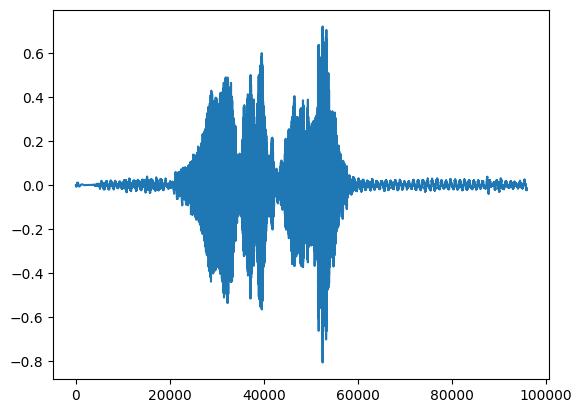

In [8]:
plt.plot(recorded_data[0])
plt.show()

#### data analysis

In [ ]:
# initialize impedance analyzer
analyzer_12 = ImpedanceAnalyzer(mic1_pos = MIC1_POS, mic2_pos = MIC2_POS, mic1_time_data = data1, mic2_time_data = data2, fs = SAMPLE_RATE, temp_c = TEMPERATURE)
analyzer_13 = ImpedanceAnalyzer(mic1_pos = MIC1_POS, mic2_pos = MIC3_POS, mic1_time_data = data1, mic2_time_data = data3, fs = SAMPLE_RATE, temp_c = TEMPERATURE)
# calculate impedance
freqs = analyzer_12.freqs
impedance_12 = analyzer_12.impedance
impedance_13 = analyzer_13.impedance    
# calculate absorption coefficient
alpha_12 = analyzer_12.alpha    
alpha_13 = analyzer_13.alpha
# plot results
analyzer_12.plot_results()
analyzer_13.plot_results()

Initialized ImpedanceAnalyzer with mic1_pos=2m, mic2_pos=2.55m, temp=25.0°C, fs=48000Hz
Initialized ImpedanceAnalyzer with mic1_pos=2m, mic2_pos=2.95m, temp=25.0°C, fs=48000Hz
